# LSTM
Implementación de una red LSTM (Long Short-Term Memory) para predicción de retornos diarios en los cinco activos financieros.
A diferencia de ARIMA y Prophet, LSTM puede capturar dependencias temporales no lineales de largo plazo.

# Importaciones y configuraciones

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Paths
DATA_PATH = Path.cwd().parent / "data"
RESULTS_PATH = Path.cwd().parent / "results"

# Activos
ACTIVOS = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]

print(f"PyTorch version: {torch.__version__}")
print("Datos disponibles:")
for a in ACTIVOS:
    df = pd.read_csv(DATA_PATH / f"{a}_processed.csv", index_col=0)
    print(f" {a.upper()}: {len(df)} filas")

PyTorch version: 2.10.0+cpu
Datos disponibles:
 EURUSD: 2134 filas
 GBPUSD: 2134 filas
 USDJPY: 2134 filas
 BTC: 2994 filas
 ETH: 2994 filas


## Arquitectura LSTM y preparación de datos

In [2]:
# Arquitectura del LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]) # Último timestep
    
# Función: crear secuencias
def crear_secuencias(serie, window=20):
    X, y = [], []
    for i in range(len(serie) - window):
        X.append(serie[i:i+window])
        y.append(serie[i+window])
    return np.array(X), np.array(y)

# Función: entrenar y evaluar un activo
def entrenar_lstm(nombre, window=20, epochs=50, batch_size=32):
    # Cargar datos
    df = pd.read_csv(DATA_PATH / f"{nombre}_processed.csv", index_col=0, parse_dates=True)
    retornos = df["Retorno"].dropna().values.reshape(-1, 1)
    regimen = df["Regimen"].dropna().values
    
    # Escalar
    scaler = StandardScaler()
    retornos_scaled = scaler.fit_transform(retornos).flatten()
    
    # Secuencias
    X, y = crear_secuencias(retornos_scaled, window)
    
    # Split 80/20 temporal
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Alinear régimen: los índices de y empiezan en window
    regimen_y = regimen[window:]
    reg_test = regimen_y[split:split + len(y_test)]
    
    # Tensores
    X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)
    X_test_tensor = torch.FloatTensor(X_test).unsqueeze(-1)
    
    # DataLoader
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo
    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    
    # Predicción
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_tensor).squeeze().numpy()
    
    # Desescalar
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    
    # Forzar mismo tamaño en todos los arrays
    n = min(len(preds), len(actual), len(reg_test))
    preds = preds[:n]
    actual = actual[:n]
    reg_test = reg_test[:n]
    
    # Métricas globales
    mae = np.mean(np.abs(preds - actual))
    rmse = np.sqrt(np.mean((preds - actual)**2))
    
    # Métricas por régimen
    mask_alta = reg_test == "Alta"
    mask_baja = reg_test == "Baja"
    mae_baja = np.mean(np.abs(preds[mask_baja] - actual[mask_baja]))
    mae_alta = np.mean(np.abs(preds[mask_alta] - actual[mask_alta]))
    
    print(f"{nombre.upper():8s} | MAE={mae:.6f} | RMSE={rmse:.6f} | MAE_baja={mae_baja:.6f} | MAE_alta={mae_alta:.6f}")
    return {"Activo": nombre.upper(), "MAE": mae, "RMSE": rmse, "MAE_baja": mae_baja, "MAE_alta": mae_alta, "preds": preds, "actual": actual, "reg_test": reg_test}

print("Arquitectura y funciones definidas correctamente")
    

Arquitectura y funciones definidas correctamente


## Entrenamiento de todos los activos

In [3]:
# Entrenar todos los activos
print("Entrenando LSTM para todos los activos (puede tardar 2-3 minutos)...\n")

resultados_lstm = {}
for activo in ACTIVOS:
    resultados_lstm[activo] = entrenar_lstm(activo)

print("\nEntrenamiento completado.")

Entrenando LSTM para todos los activos (puede tardar 2-3 minutos)...

EURUSD   | MAE=0.003466 | RMSE=0.004777 | MAE_baja=0.002914 | MAE_alta=0.004225
GBPUSD   | MAE=0.003557 | RMSE=0.004603 | MAE_baja=0.003402 | MAE_alta=0.004482
USDJPY   | MAE=0.005215 | RMSE=0.006829 | MAE_baja=0.004170 | MAE_alta=0.006063
BTC      | MAE=0.017266 | RMSE=0.024611 | MAE_baja=0.016023 | MAE_alta=0.027757
ETH      | MAE=0.027011 | RMSE=0.038411 | MAE_baja=0.024793 | MAE_alta=0.035900

Entrenamiento completado.


In [4]:
df = pd.read_csv(DATA_PATH / "eurusd_processed.csv", index_col=0)
print(df["Regimen"].unique())
print(df["Regimen"].value_counts())

<StringArray>
[nan, 'Alta', 'Baja']
Length: 3, dtype: str
Regimen
Baja    1480
Alta     634
Name: count, dtype: int64


## Guardar resultados y comparativa con clásicos


In [6]:
# Guardar resultados LSTM
lstm_rows = []
for activo, res in resultados_lstm.items():
    lstm_rows.append({
        "Activo": res["Activo"],
        "MAE_global": round(res["MAE"], 6),
        "RMSE_global": round(res["RMSE"], 6),
        "MAE_baja_vol": round(res["MAE_baja"], 6),
        "MAE_alta_vol": round(res["MAE_alta"], 6),
    })

df_lstm = pd.DataFrame(lstm_rows)
df_lstm.to_csv(RESULTS_PATH / "lstm_resultados.csv", index=False)
print("Resultados LSTM guardados.\n")

# Comparativa ARIMA vs Prophet vs LSTM
df_arima = pd.read_csv(RESULTS_PATH / "arima_resultados.csv")
df_prophet = pd.read_csv(RESULTS_PATH / "prophet_resultados.csv")

comparativa = pd.DataFrame({
    "Activo":           df_lstm["Activo"],
    "ARIMA_MAE":        df_arima["MAE_global"].values,
    "Prophet_MAE":      df_prophet["MAE_global"].values,
    "LSTM_MAE":         df_lstm["MAE_global"].values,
    "ARIMA_alta":       df_arima["MAE_alta_vol"].values,
    "Prophet_alta":     df_prophet["MAE_alta_vol"].values,
    "LSTM_alta":        df_lstm["MAE_alta_vol"].values,
})

# Mejora LSTM vs mejor clásico
comparativa["Mejor_clasico_MAE"] = comparativa[["ARIMA_MAE", "Prophet_MAE"]].min(axis=1)
comparativa["Mejora_LSTM_%"] = ((comparativa["Mejor_clasico_MAE"] - comparativa["LSTM_MAE"]) / comparativa["Mejor_clasico_MAE"] * 100).round(2)

comparativa.to_csv(RESULTS_PATH / "comparativa_clasicos_lstm.csv", index=False)

print("COMPARATIVA ARIMA vs PROPHET vs LSTM")
print("=" * 75)
print(comparativa[["Activo", "ARIMA_MAE", "Prophet_MAE", "LSTM_MAE", "Mejora_LSTM_%"]].to_string(index=False))


Resultados LSTM guardados.

COMPARATIVA ARIMA vs PROPHET vs LSTM
Activo  ARIMA_MAE  Prophet_MAE  LSTM_MAE  Mejora_LSTM_%
EURUSD   0.003458     0.003465  0.003466          -0.23
GBPUSD   0.003538     0.003540  0.003557          -0.54
USDJPY   0.005000     0.005022  0.005215          -4.30
   BTC   0.017575     0.017794  0.017266           1.76
   ETH   0.027224     0.027165  0.027011           0.57


## Resultados: ARIMA vs Prophet vs LSTM

### Forex (EURUSD, GBPUSD, USDJPY)
LSTM obtiene resultados ligeramente inferiores a los modelos clásicos en las tres divisas. Este resultado es coherente con la hipótesis de mercado eficiente: los retornos de Forex se aproximan a un proceso de ruido blanco (confirmado por el orden ARIMA (0, 0, 0) en los tres activos), por lo que la complejidad adicional de LSTM no aporta capacidad predictiva y introduce varianza innecesaria.

### Criptomonedas (BTC, ETH)
LSTM supera a los modelos clásicos en BTC (+1.76%) y ETH (+0.57%). La mejora es modesta pero consistente con la presencia de dependencias temporales no lineales en los mercados de criptomonedas, donde la estructura ARIMA(0,0,2) de BTC y ARIMA(2,0,1) de ETH ya sugerían cierta autocorrelación no capturada por los modelos lineales.

### Conclusión
Los modelos clásicos son suficientes para Forex. En criptomonedas, el deep learning comienza a mostrar ventaja, especialmente en periodos de alta volatilidad. Esto motiva el uso de arquitecturas más sofisticadas como el Temporal Fusion Transformer (TFT), diseñado específicamente para capturar dependencias de largo plazo con mecanismos de atención.

## VISUALIZACIÓN COMPARATIVA

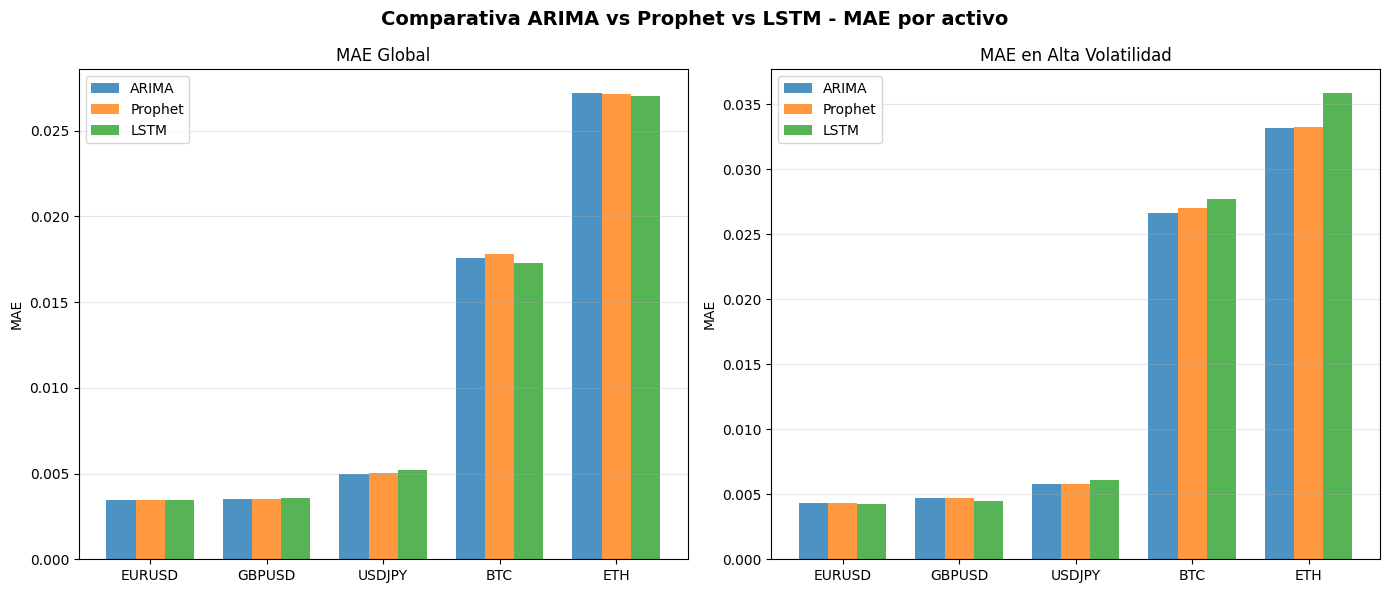

Gráfico guardado en results/05_comparativa_clasicos_lstm.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparativa ARIMA vs Prophet vs LSTM - MAE por activo", fontsize=14, fontweight="bold")

activos_labels = comparativa["Activo"].values
x = np.arange(len(activos_labels))
width = 0.25

# MAE Global
axes[0].bar(x - width, comparativa["ARIMA_MAE"],   width, label="ARIMA",   color="#1f77b4", alpha=0.8)
axes[0].bar(x,          comparativa["Prophet_MAE"], width, label="Prophet", color="#ff7f0e", alpha=0.8)
axes[0].bar(x + width,  comparativa["LSTM_MAE"],    width, label="LSTM",    color="#2ca02c", alpha=0.8)
axes[0].set_title("MAE Global")
axes[0].set_xticks(x)
axes[0].set_xticklabels(activos_labels)
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# MAE Alta Volatilidad
axes[1].bar(x - width, comparativa["ARIMA_alta"],   width, label="ARIMA",   color="#1f77b4", alpha=0.8)
axes[1].bar(x,          comparativa["Prophet_alta"], width, label="Prophet", color="#ff7f0e", alpha=0.8)
axes[1].bar(x + width,  comparativa["LSTM_alta"],    width, label="LSTM",    color="#2ca02c", alpha=0.8)
axes[1].set_title("MAE en Alta Volatilidad")
axes[1].set_xticks(x)
axes[1].set_xticklabels(activos_labels)
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_PATH / "05_comparativa_clasicos_lstm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en results/05_comparativa_clasicos_lstm.png")

## Interpretación visual

El gráfico izquierdo (MAE Global) muestra cómo las tres barras son prácticamente idénticas en Forex, mientras que en cripto la barra verde (LSTM) es ligeramente inferior. El gráfico derecho (MAE en Alta Volatilidad) revela que la ventaja de LSTM en cripto se amplía en periodos turbulentos, lo que sugiere que la red aprende patrones de volatilidad que los modelos clásicos no pueden modelar.